In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd
import json

import igl 
from scipy.sparse.linalg import eigsh
from scipy import sparse 
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

from scipy.special import digamma, gamma
from collections import defaultdict

In [2]:
import importlib
import src.meshharm
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)


from src import utils 
from src.fatemarkers import FateMarkers
from src.ksg_estimators import KSGEstimator

In [3]:
# path = 'Data/20260211/'
path = 'Data/20260224'

with open(f"{path}/config.json", 'r') as f:
    cfg = json.load(f)
timepoints  = cfg['timepoints']
zarr_names  = cfg['zarr_names']
wells       = cfg['wells']
rounds      = cfg['rounds']
times_dic   = cfg['times_dic'] 
annotation_names = cfg['annotation_names']

In [4]:
# state an order 
correct_order = list(annotation_names.keys())

In [ ]:
# Load everything precomputed by compute_master_npz.py
# (replaces the old per-organoid loading loop + 95th-percentile filtering)
master = np.load(f"{path}/master.npz", allow_pickle=True)

ids                = master['ids']
filtered_ids       = master['ids']
times              = master['times']
filtered_times     = master['times']
filtered_areas     = master['mass_areas']      # original 'A' = mass_matrix diag sum
coeffs_fm_filtered = master['fm_coeffs']         # (N, n_modes^2, n_fates)
filtered_hks       = master['hks_coeffs_sparse'] # (N, n_modes^2, 4)
sparse_ts          = [1, 4, 25, 100]            # time-scales of hks_coeffs_sparse

print(filtered_hks.shape, coeffs_fm_filtered.shape)

In [31]:
coeffs = np.concatenate([np.array(coeffs_fm_filtered), filtered_hks], axis=-1)

hks_names = [f'hks-{i}' for i in range(filtered_hks.shape[-1])]
names = correct_order + hks_names 
print(names)

['lgr', 'chroma', 'cycd', 'muc', 'aldob', 'gluc', 'cyca', 'agr', 'sero', 'lyz', 'hks-0', 'hks-1', 'hks-2', 'hks-3']


In [40]:
print(coeffs.shape) 

(2671, 225, 14)


In [46]:
for (i, fate) in enumerate(correct_order):
    print(fate)

    has_fate = (np.abs(coeffs[:, 0, i]) > 0).astype('int')
    print(has_fate.sum()/len(has_fate))

lgr
0.4178210408086859
chroma
0.22126544365406214
cycd
0.7057281916885062
muc
0.36428304005990264
aldob
0.4346686634219393
gluc
0.03631598652190191
cyca
0.822163983526769
agr
0.5503556720329464
sero
0.21153126169973793
lyz
0.3373268438786971


        label_uid      tsne1      tsne2  complexity
0   day1p5_A01_96  -7.494033 -37.650530    1.954743
1  day1p5_A01_140 -13.043761 -34.288180    1.957939
2  day1p5_A01_154 -17.446129 -28.724447    1.959774
3   day1p5_A01_41 -23.943840 -28.737452    1.959741
4   day1p5_A01_68  -4.886186 -54.626280    1.954796
(2530, 4)


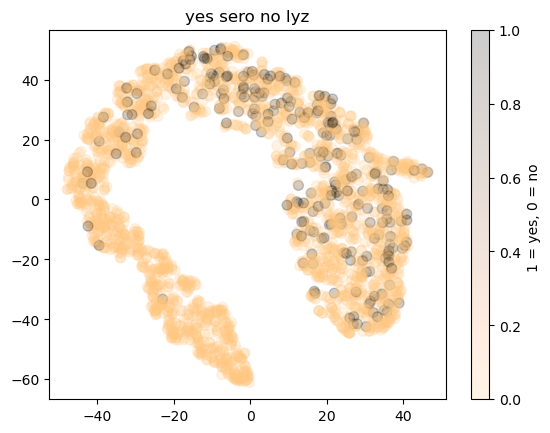

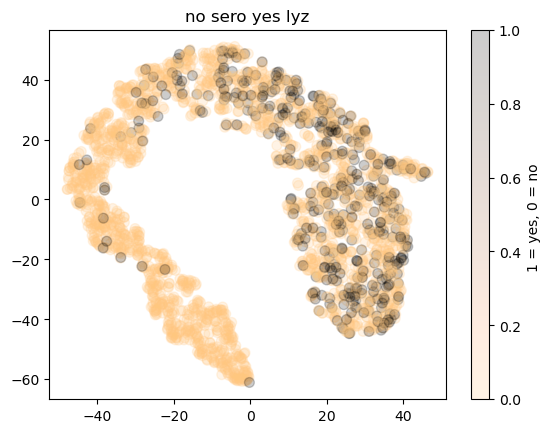

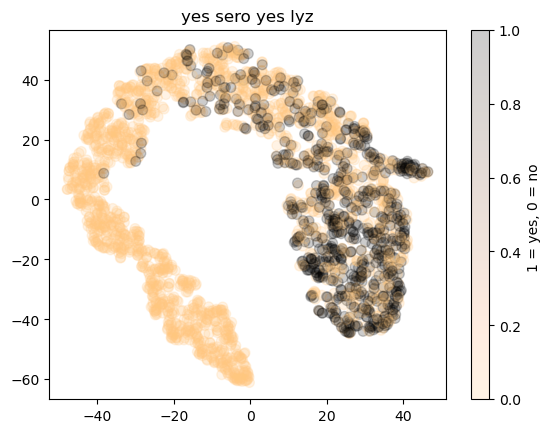

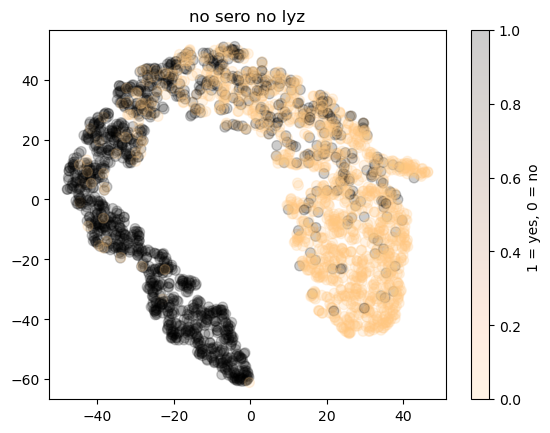

In [32]:
dim_red_results = pd.read_csv(f'{path}/tsne_results_raw_value.csv')
print(dim_red_results.head())
print(dim_red_results.shape)

indices = np.where(dim_red_results['label_uid'].isin(ids))[0]

sero_mask = np.abs(coeffs_fm_filtered[indices, 0, 3]) > 0
lyz_mask = np.abs(coeffs_fm_filtered[indices, 0, 4]) > 0

plt.scatter(dim_red_results['tsne1'], dim_red_results['tsne2'], c=sero_mask & ~lyz_mask, cmap='copper_r', s=50, alpha=0.2)
plt.colorbar(label='1 = yes, 0 = no ')
plt.title('yes sero no lyz')
plt.show()

plt.scatter(dim_red_results['tsne1'], dim_red_results['tsne2'], c=~sero_mask & lyz_mask, cmap='copper_r', s=50, alpha=0.2)
plt.colorbar(label='1 = yes, 0 = no ')
plt.title('no sero yes lyz')
plt.show()

plt.scatter(dim_red_results['tsne1'], dim_red_results['tsne2'], c=sero_mask & lyz_mask, cmap='copper_r', s=50, alpha=0.2)
plt.colorbar(label='1 = yes, 0 = no ')
plt.title('yes sero yes lyz')
plt.show()

plt.scatter(dim_red_results['tsne1'], dim_red_results['tsne2'], c=~sero_mask & ~lyz_mask, cmap='copper_r', s=50, alpha=0.2)
plt.colorbar(label='1 = yes, 0 = no ')
plt.title('no sero no lyz')
plt.show()

# for i in range(len(correct_order)): 
#     plt.scatter(dim_red_results['tsne1'], dim_red_results['tsne2'], c=(np.abs(coeffs_fm_filtered[indices, 0, i]) > 0), cmap='copper_r', s=50)
#     plt.colorbar(label='1 = yes, 0 = no ')
#     plt.title(f't-SNE colored by average {correct_order[i]}')
#     plt.show()  


In [33]:
import math

def plot_matrices(matrices, title='Correlation', cmap='viridis'): 

    # Loop over all matrices for each timepoint
    unique_times_list = np.unique(times)
    n_timepoints = len(unique_times_list)

    short_names = names 

    # Calculate number of rows needed for 2 columns
    n_cols = 4
    n_rows = math.ceil(n_timepoints / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()  # Flatten in case axes is 2D

    if cmap == 'PiYG' or cmap == 'bwr': 
        vmax = max(np.max(matrices), -np.min(matrices))
        vmin = -vmax
    if cmap == 'viridis': 
        vmin = None
        vmax = None

    for idx, (mi_matrix, timepoint) in enumerate(zip(matrices, unique_times_list)):
        n_features = mi_matrix.shape[0]
        
        # Plot 2: Without diagonal elements
        mask = np.eye(n_features, dtype=bool)
        mi_matrix_masked = np.copy(mi_matrix)
        mi_matrix_masked[mask] = np.nan

        im2 = axes[idx].imshow(mi_matrix_masked, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        plt.colorbar(im2, ax=axes[idx], label=f'{title}')
        axes[idx].set_xticks(ticks=np.arange(n_features))
        axes[idx].set_xticklabels(short_names, rotation=90, ha='right')
        axes[idx].set_yticks(ticks=np.arange(n_features))
        axes[idx].set_yticklabels(short_names)
        axes[idx].set_title(f'{title} (no diagonal) - Day {timepoint}')

    # Hide any unused subplots
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [12]:
ksg = KSGEstimator()

coeffs_rescaled = np.empty_like(coeffs) 

for i in range(coeffs.shape[-1]):
    scaler = StandardScaler()
    coeffs_rescaled[:, :, i] = scaler.fit_transform(coeffs[:, :, i])

mi_matrices = [] 
for t in np.unique(times): 
    mask = (filtered_times == t) 
    print(int(np.sum(mask)), t)
    mi_matrix = np.zeros((coeffs.shape[-1], coeffs.shape[-1]))
    masked_coeffs = coeffs_rescaled[mask, :, :] 
    for i in range(coeffs.shape[-1]): 
        for j in range(0, i+1): 

            X = np.copy(masked_coeffs[:, :, i])
            Y = np.copy(masked_coeffs[:, :, j])
            mi_matrix[i, j] = ksg.mutual_information(X, Y, method=2)
    mi_matrices.append(mi_matrix)


378 1p5


KeyboardInterrupt: 

In [131]:
np.savez('sim/fm_coeffs_wo_encoding.npz', 
         filtered_time=filtered_times,
         coeffs=coeffs, 
         names=names, 
         mi=np.array(matrices)
         )

np.save('sim/mi.npy', np.array(matrices))


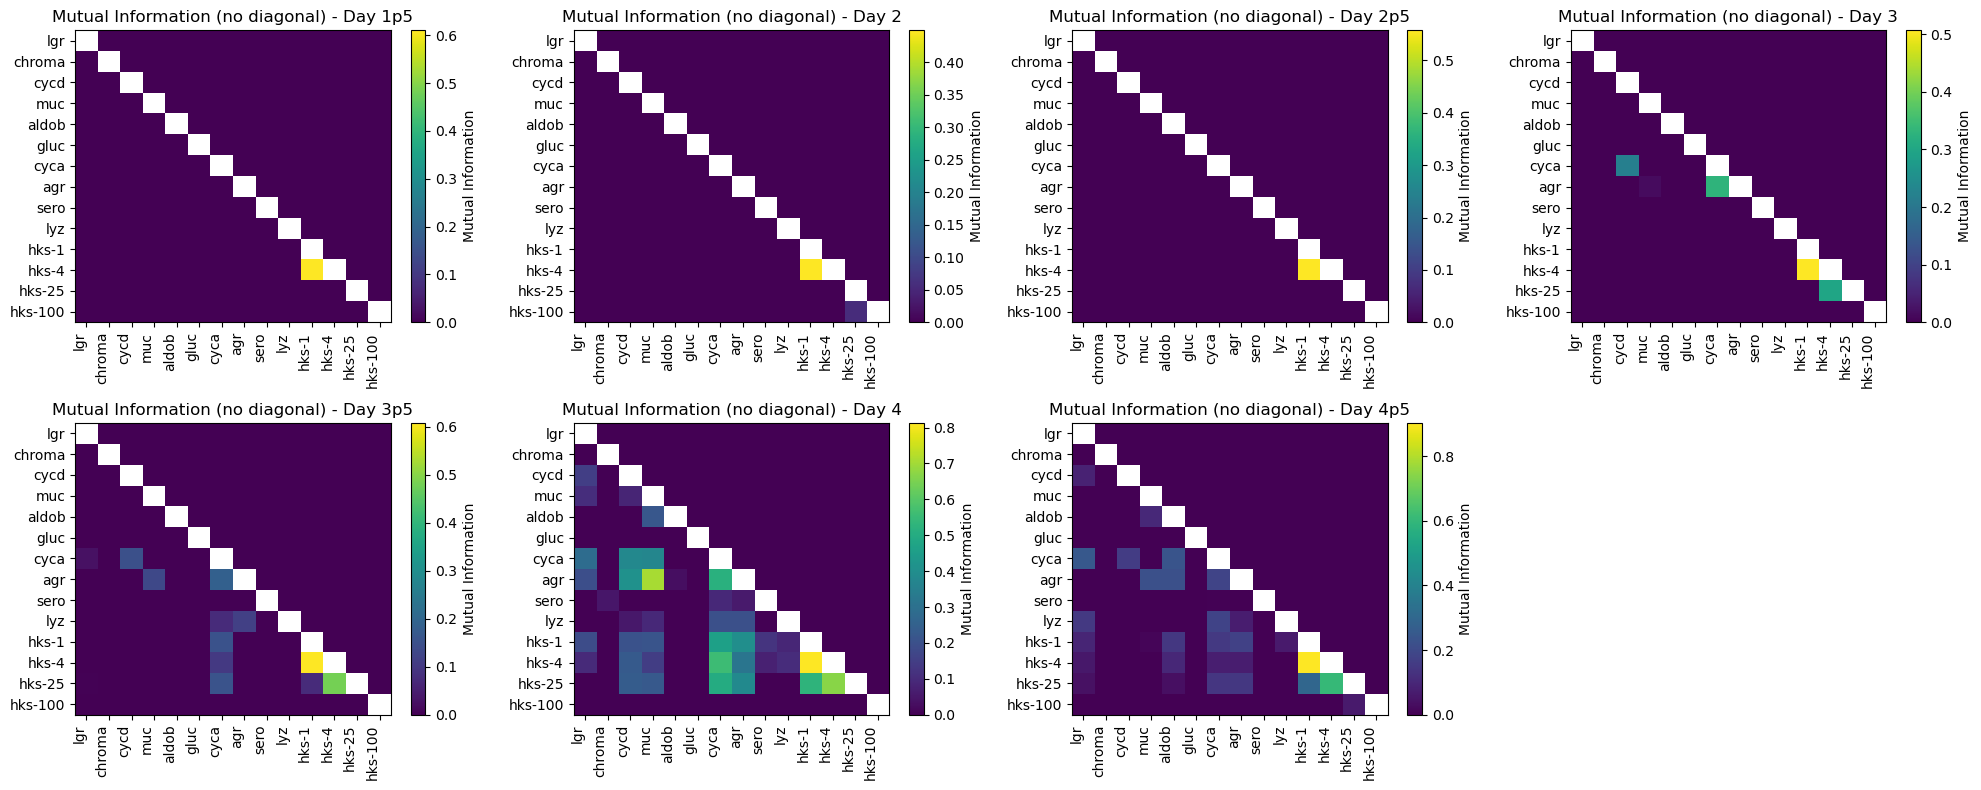

In [45]:
plot_matrices(mi_matrices)

In [13]:
def compute_corr(X, Y, A):
    # X shape: (n_samples, n_coefficients)
    corr = np.sum(np.sum(X * Y, axis=1)/A)/X.shape[0]
    x_var = np.sum(np.sum(X * X, axis=1)/A)/X.shape[0] 
    y_var = np.sum(np.sum(Y * Y, axis=1)/A)/X.shape[0] 
    return corr, x_var, y_var

In [34]:
corr_matrices = [] 


vars = np.sum(coeffs[:, 1:]*coeffs[:, 1:], axis=1)/filtered_areas[:, np.newaxis]
vars = np.sum(vars, axis=0)/vars.shape[0]

print(vars.shape) 
for t in np.unique(times): 
    mask = (filtered_times == t) 
    print(int(np.sum(mask)), t)
    corr_matrix = np.zeros((coeffs.shape[-1], coeffs.shape[-1]))
    masked_coeffs = coeffs[mask, :, :] 


    for i in range(coeffs.shape[-1]): 
        for j in range(0, i+1): 
            X = np.copy(masked_coeffs[:, 1:, i])
            Y = np.copy(masked_coeffs[:, 1:, j])
            corr, x_var, y_var = compute_corr(X, Y, filtered_areas[mask])
            if x_var < 1e-10 or y_var < 1e-10: 
                corr_matrix[i, j] = 0
            else:
                corr_matrix[i, j] = corr / np.sqrt(x_var * y_var)
                corr_matrix[j, i] = corr_matrix[i, j]
    corr_matrices.append(corr_matrix)

(14,)
378 1p5
279 2
364 2p5
463 3
303 3p5
337 4
547 4p5


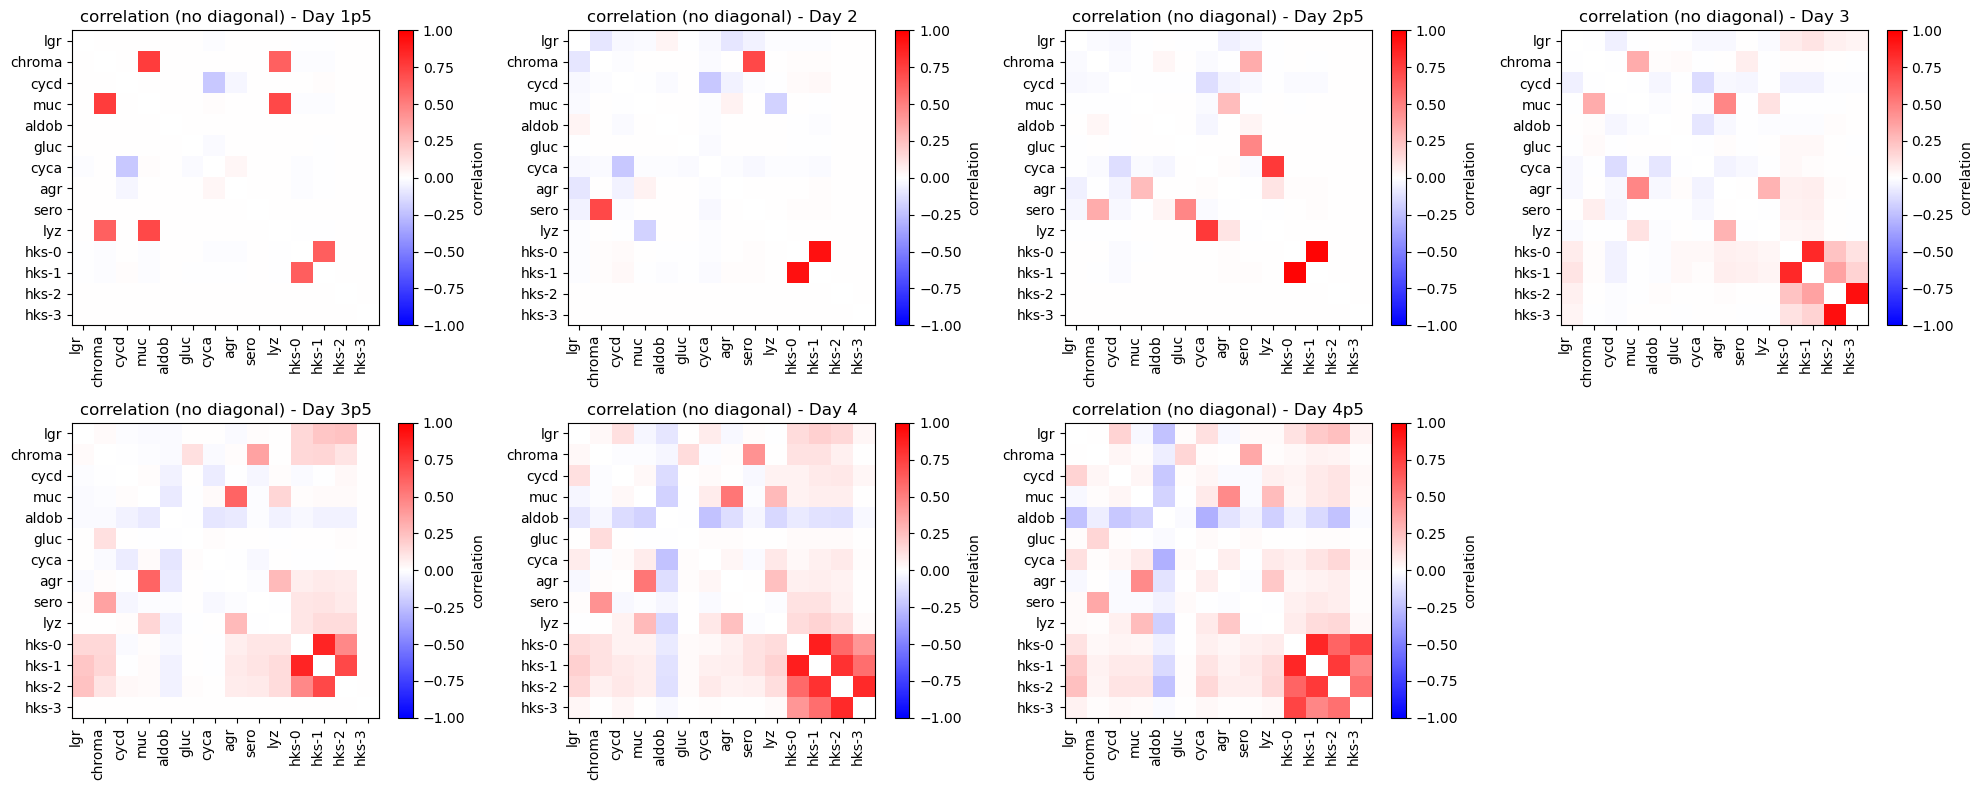

In [35]:
plot_matrices(corr_matrices, title='correlation', cmap='bwr')

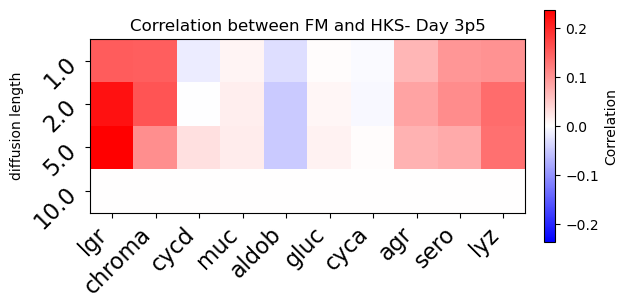

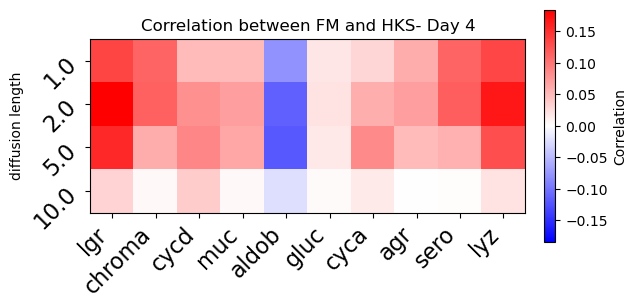

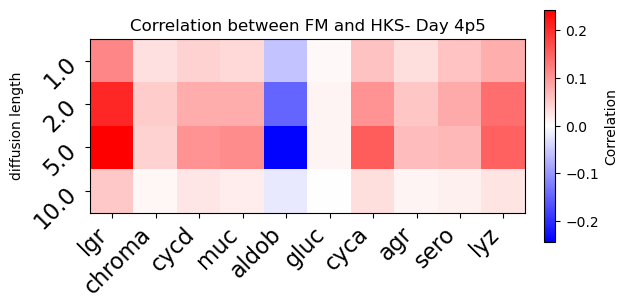

In [39]:
x_axis = correct_order
y_axis = hks_names

# plot heatmap with the selected names 
x_indices = [names.index(name) for name in x_axis]
y_indices = [names.index(name) for name in y_axis]


for d in range(4, len(corr_matrices)):
    # Create a new matrix with the selected rows and columns
    selected_corr_matrix = corr_matrices[d][np.ix_(y_indices, x_indices)]

    # Plot the heatmap
    plt.figure(figsize=(6, 5))
    plt.imshow(selected_corr_matrix, cmap='bwr', vmax=np.max(np.abs(selected_corr_matrix)), vmin=-np.max(np.abs(selected_corr_matrix)))
    plt.colorbar(label='Correlation', fraction=0.025, pad=0.04)
    plt.xticks(ticks=np.arange(len(x_axis)), labels=x_axis, rotation=45, ha='right', fontsize=16)
    plt.yticks(ticks=np.arange(len(y_axis)), labels=y_axis, rotation=45, ha='right', fontsize=16)
    plt.yticks(ticks=np.arange(len(y_axis)), labels=np.sqrt(np.array(sparse_ts)), fontsize=16)
    plt.ylabel('diffusion length')
    plt.title(f'Correlation between FM and HKS- Day {np.unique(times)[d]}')
    plt.savefig(f'Figures/corr_fm_hks_day{np.unique(times)[d]}.pdf', dpi=300, bbox_inches='tight')
    plt.show()